In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [2]:
np.random.seed(42)

n_genes = 1000
n_control = 3
n_treated = 3

base_expression = np.random.poisson(lam=100, size=(n_genes, 1))

control = np.random.poisson(lam=base_expression, size=(n_genes, n_control))
treated = np.random.poisson(lam=base_expression, size=(n_genes, n_treated))

de_genes = np.random.choice(n_genes, 50, replace=False)
treated[de_genes] = np.random.poisson(
    lam=base_expression[de_genes] * 2,
    size=(50, n_treated)
)

counts = np.hstack([control, treated])

columns = [f"control_{i+1}" for i in range(n_control)] + \
          [f"treated_{i+1}" for i in range(n_treated)]

df_large = pd.DataFrame(counts, columns=columns)
df_large["gene"] = [f"Gene_{i}" for i in range(n_genes)]

df_large.head()

,control_1,control_2,control_3,treated_1,treated_2,treated_3,gene
0,99,103,111,99,93,96,Gene_0
1,108,101,109,108,121,129,Gene_1
2,75,84,92,81,99,95,Gene_2
3,109,108,97,95,92,96,Gene_3
4,109,122,129,118,113,121,Gene_4


In [3]:
df_large.shape

(1000, 7)

In [4]:
df_large.columns

Index(['control_1', 'control_2', 'control_3', 'treated_1', 'treated_2',
       'treated_3', 'gene'],
      dtype='str')

In [5]:
sample_cols = [c for c in df_large.columns if c.startswith("control_") or c.startswith("treated_")]
sample_cols

['control_1', 'control_2', 'control_3', 'treated_1', 'treated_2', 'treated_3']

In [6]:
library_sizes = df_large[sample_cols].sum(axis=0)
library_sizes

control_1     99429
control_2     99733
control_3     99373
treated_1    104982
treated_2    104881
treated_3    104970
dtype: int64

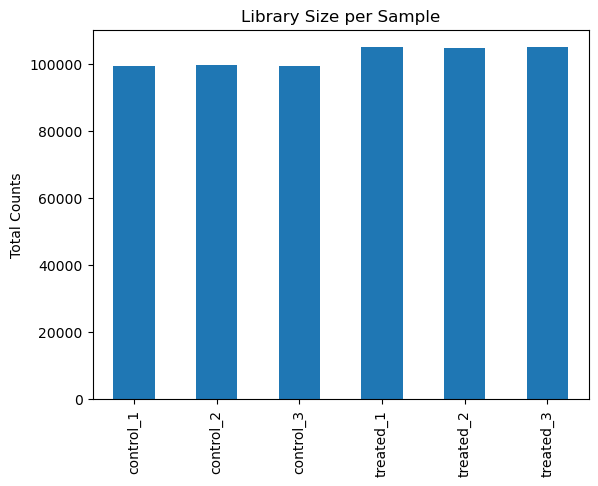

In [7]:
library_sizes.plot(kind="bar")
plt.title("Library Size per Sample")
plt.ylabel("Total Counts")
plt.show()

In [8]:
cpm = df_large.copy()

for col in sample_cols:
    cpm[col] = (df_large[col] / library_sizes[col]) * 1_000_000

cpm.head()

,control_1,control_2,control_3,treated_1,treated_2,treated_3,gene
0,995.685363,1032.757462,1117.003613,943.018803,886.719234,914.547013,Gene_0
1,1086.202215,1012.703919,1096.877421,1028.747785,1153.688466,1228.922549,Gene_1
2,754.307094,842.248804,925.804796,771.560839,943.926927,905.020482,Gene_2
3,1096.259643,1082.891320,976.120274,904.917033,877.184619,914.547013,Gene_3
4,1096.259643,1223.266121,1298.139334,1124.002210,1077.411543,1152.710298,Gene_4


In [9]:
log_cpm = cpm.copy()

for col in sample_cols:
    log_cpm[col] = np.log2(log_cpm[col] + 1)

log_cpm.head()

,control_1,control_2,control_3,treated_1,treated_2,treated_3,gene
0,9.960994,10.013682,10.126709,9.882672,9.793960,9.838490,Gene_0
1,10.086405,9.985421,10.100501,10.008075,10.173288,10.264352,Gene_1
2,9.560920,9.719815,9.856122,9.593505,9.884059,9.823400,Gene_2
3,10.099689,10.082004,9.932392,9.823235,9.778380,9.838490,Gene_3
4,10.099689,10.257701,10.343340,10.135712,10.074692,10.172065,Gene_4


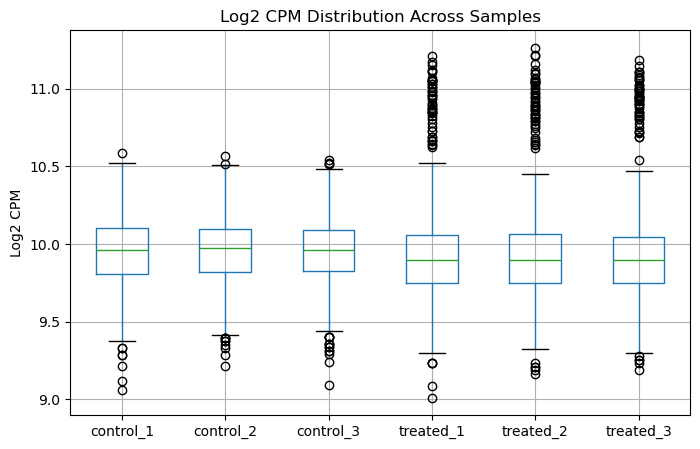

In [10]:
plt.figure(figsize=(8,5))
log_cpm[sample_cols].boxplot()
plt.title("Log2 CPM Distribution Across Samples")
plt.ylabel("Log2 CPM")
plt.show()

In [11]:
log_cpm["control_mean"] = log_cpm[["control_1","control_2","control_3"]].mean(axis=1)
log_cpm["treated_mean"] = log_cpm[["treated_1","treated_2","treated_3"]].mean(axis=1)

log_cpm["log2FC"] = log_cpm["treated_mean"] - log_cpm["control_mean"]

log_cpm[["gene","log2FC"]].head()

,gene,log2FC
0,Gene_0,-0.195421
1,Gene_1,0.091130
2,Gene_2,0.054703
3,Gene_3,-0.224660
4,Gene_4,-0.106087


In [14]:
for c in sample_cols:
    log_cpm[c] = pd.to_numeric(log_cpm[c], errors="coerce")

log_cpm[sample_cols].dtypes

control_1    float64
control_2    float64
control_3    float64
treated_1    float64
treated_2    float64
treated_3    float64
dtype: object

In [16]:
p_values = []
t_stats = []

for _, row in log_cpm.iterrows():
    control_vals = row[["control_1","control_2","control_3"]].to_numpy(dtype=float)
    treated_vals = row[["treated_1","treated_2","treated_3"]].to_numpy(dtype=float)

    t_stat, p_val = ttest_ind(control_vals, treated_vals, equal_var=False)

    t_stats.append(t_stat)
    p_values.append(p_val)

log_cpm["t_stat"] = t_stats
log_cpm["p_value"] = p_values

log_cpm[["gene", "log2FC", "t_stat", "p_value"]].head()

,gene,log2FC,t_stat,p_value
0,Gene_0,-0.195421,3.541189,0.037908
1,Gene_1,0.091130,-1.093968,0.356791
2,Gene_2,0.054703,-0.445061,0.679328
3,Gene_3,-0.224660,4.008430,0.040066
4,Gene_4,-0.106087,1.381175,0.273286


In [17]:
log_cpm[sample_cols].isna().sum()

control_1    0
control_2    0
control_3    0
treated_1    0
treated_2    0
treated_3    0
dtype: int64

In [18]:
from statsmodels.stats.multitest import multipletests

adjusted = multipletests(log_cpm["p_value"], method="fdr_bh")

log_cpm["FDR"] = adjusted[1]

log_cpm.head()

,control_1,control_2,control_3,treated_1,treated_2,treated_3,gene,control_mean,treated_mean,log2FC,t_stat,p_value,FDR
0,9.960994,10.013682,10.126709,9.882672,9.793960,9.838490,Gene_0,10.033795,9.838374,-0.195421,3.541189,0.037908,0.399252
1,10.086405,9.985421,10.100501,10.008075,10.173288,10.264352,Gene_1,10.057442,10.148572,0.091130,-1.093968,0.356791,0.795183
2,9.560920,9.719815,9.856122,9.593505,9.884059,9.823400,Gene_2,9.712285,9.766988,0.054703,-0.445061,0.679328,0.906439
3,10.099689,10.082004,9.932392,9.823235,9.778380,9.838490,Gene_3,10.038029,9.813369,-0.224660,4.008430,0.040066,0.406002
4,10.099689,10.257701,10.343340,10.135712,10.074692,10.172065,Gene_4,10.233577,10.127490,-0.106087,1.381175,0.273286,0.744146


In [19]:
significant = log_cpm[(log_cpm["FDR"] < 0.05) & (abs(log_cpm["log2FC"]) > 1)]

significant.shape

(6, 13)

In [20]:
significant[["gene","log2FC","p_value","FDR"]]

,gene,log2FC,p_value,FDR
32,Gene_32,1.006937,0.000983,0.044671
444,Gene_444,1.025022,0.000541,0.033844
482,Gene_482,1.145739,0.000309,0.029542
569,Gene_569,1.066657,0.000115,0.029542
796,Gene_796,1.024541,0.000436,0.031159
947,Gene_947,1.022607,0.000436,0.031159


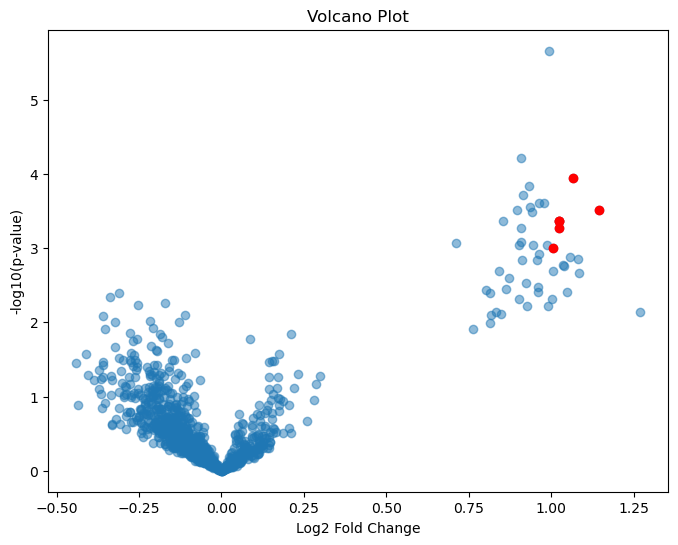

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(log_cpm["log2FC"], -np.log10(log_cpm["p_value"]), alpha=0.5)

sig = (log_cpm["FDR"] < 0.05) & (abs(log_cpm["log2FC"]) > 1)

plt.scatter(
    log_cpm.loc[sig,"log2FC"],
    -np.log10(log_cpm.loc[sig,"p_value"]),
    color="red"
)

plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot")
plt.show()

In [22]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 14.6 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [23]:
from sklearn.decomposition import PCA

X = log_cpm[sample_cols].T
X.shape

(6, 1000)

In [24]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_pca

array([[-4.03256942, -3.247738  ],
       [-4.04583792,  1.3624646 ],
       [-3.93998494,  1.83594747],
       [ 3.82646188,  1.35214128],
       [ 4.03336268,  0.85367058],
       [ 4.15856771, -2.15648593]])

In [25]:
samples = sample_cols

labels = ["Control","Control","Control","Treated","Treated","Treated"]

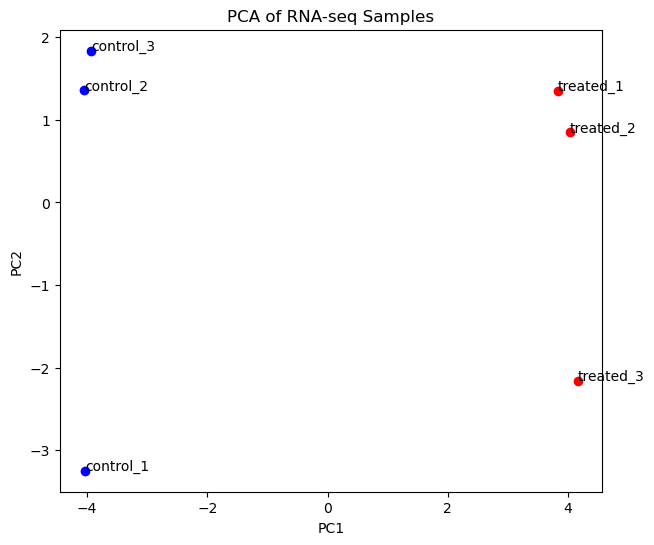

In [26]:
plt.figure(figsize=(7,6))

for i in range(len(samples)):
    
    if labels[i] == "Control":
        plt.scatter(X_pca[i,0], X_pca[i,1], color="blue")
    else:
        plt.scatter(X_pca[i,0], X_pca[i,1], color="red")

    plt.text(X_pca[i,0], X_pca[i,1], samples[i])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of RNA-seq Samples")

plt.show()

In [27]:
Right click project root
New Folder
docs

SyntaxError: invalid syntax (309797664.py, line 1)